In [25]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as scpy
import xarray as xr
from scipy import optimize
from tqdm import tqdm


In [ ]:
ds = xr.open_dataset('/Users/lbaker/Documents/copied_from_ptolemy/combined_output_filtered_Eulerian_Lagrangian_Ro_0_1_B00.nc', decode_times=False)

In [10]:
x = ds.x_caa.values
z = ds.z_aac.values
t = ds.time.values

f = 1e-4               # Coriolis frequency [s⁻¹]
L_front = 10000  # Initial front width [m]
aspect_ratio = 100      # L_front/H
δ = 0                   # Strain ratio (α/f)
Ro = 0.1   
H_front = L_front/aspect_ratio

M2 = (Ro**2*f**2*L_front)/H_front
db = M2*L_front

In [67]:

def b_i(x):
    return db*np.sin(2*np.pi/L_front * x)

def db_i_dx(x):
    return (2*np.pi/L_front) * db * np.cos(2*np.pi/L_front * x)

def T_i(x):
    return np.exp(-(x/(L_front/20))**2)

def v(x0,z,t):
    return -(1/f)*db_i_dx(x0)*(H_front/2 - z)*(1 - np.cos(f*t))

def find_x0(x0,x,z,t):
    return x0 - x + (1/f**2)*db_i_dx(x0)*(-H_front/2 - z)*(1 - np.cos(f*t))

In [70]:

# ds["b_B00"] =ds.b.copy(data = ds.b.values*0) 
# ds["T_B00"] =ds.b.copy(data = ds.b.values*0) 
# ds["v_B00"] =ds.b.copy(data = ds.b.values*0) 
# ds["x0"]=ds.b.copy(data = ds.b.values*0)
Hx = ds.Hx.values
for it in tqdm(range(25,len(t))):
    for ix in range(len(x)):
        for iz in range(len(z)):
            
            sol = optimize.root_scalar(find_x0, args = (x[ix],z[iz],t[it]),x0=x[ix], method='bisect', bracket=[x[ix]-2000, x[ix]+2000], xtol=1e-6, rtol=1e-6)
            x0 = sol.root
            x0 -= np.floor((x0-x[Hx])/(x[-Hx]-x[Hx]))*(x[-Hx]-x[Hx])  # Ensure x0 is within the domain of x
            ds["x0"][it,iz,0,ix] = x0
            ds["b_B00"][it,iz,0,ix] = b_i(x0)
            ds["T_B00"][it,iz,0,ix] = T_i(x0)
            ds["v_B00"][it,iz,0,ix] = v(x0,z[iz],t[it])


100%|██████████| 96/96 [17:56<00:00, 11.21s/it]


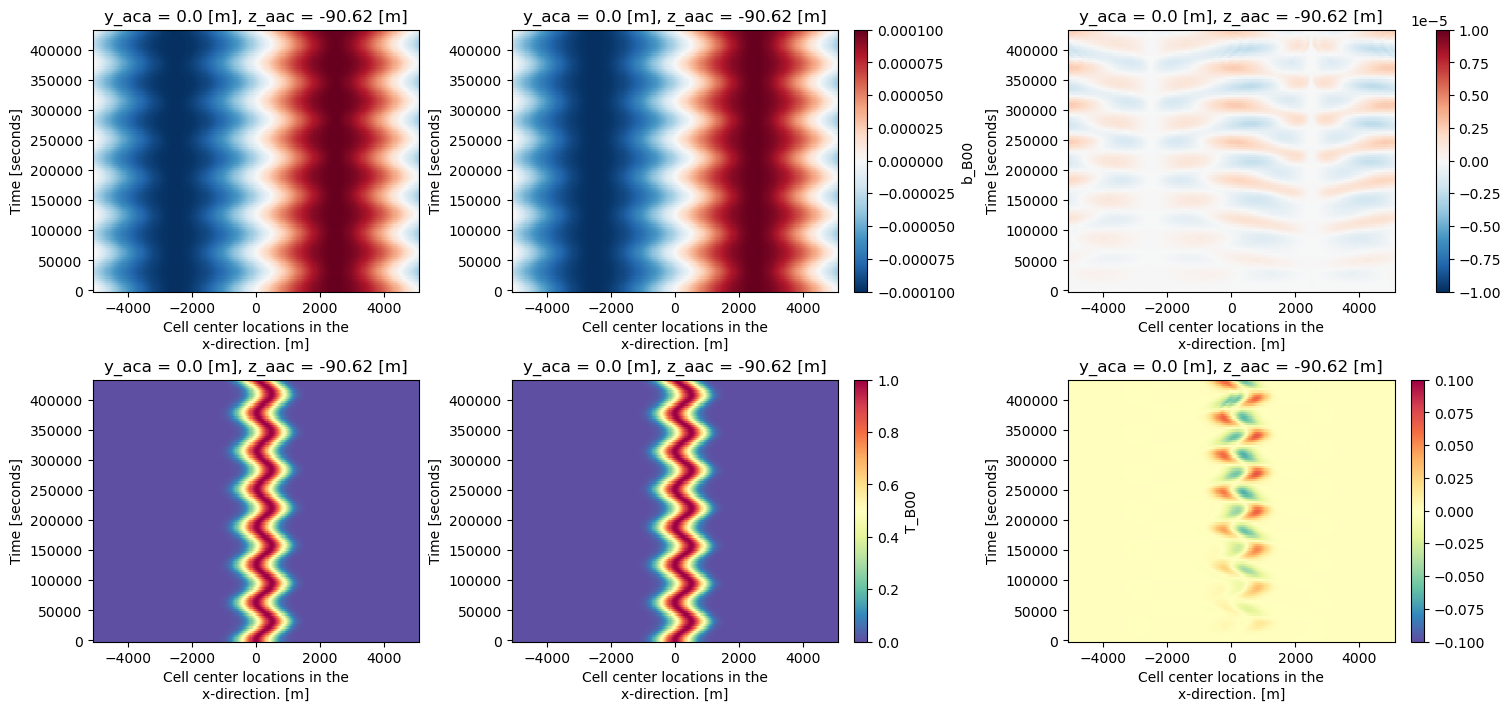

In [81]:
fig, ax = plt.subplots(2,3, figsize=(15,7),constrained_layout=True)
ds.b[:,10,0,:].plot(ax=ax[0,0], cmap = 'RdBu_r', vmin=-1e-4, vmax=1e-4,add_colorbar=False)
ds.b_B00[:,10,0,:].plot(ax=ax[0,1], cmap = 'RdBu_r', vmin=-1e-4, vmax=1e-4,add_colorbar=True)
(ds.b_B00 - ds.b)[:,10,0,:].plot(ax=ax[0,2], cmap = 'RdBu_r', vmin=-1e-5, vmax=1e-5,add_colorbar=True)
ds.T[:,10,0,:].plot(ax=ax[1,0], cmap = 'Spectral_r', vmin=0, vmax=1,add_colorbar=False)
ds.T_B00[:,10,0,:].plot(ax=ax[1,1], cmap = 'Spectral_r', vmin=0, vmax=1,add_colorbar=True)
(ds.T_B00 - ds.T)[:,10,0,:].plot(ax=ax[1,2], cmap = 'Spectral_r', vmin=-1e-1, vmax=1e-1,add_colorbar=True)


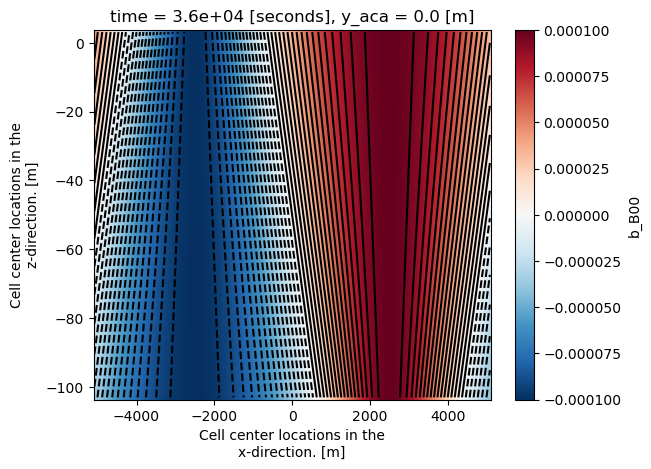

In [77]:
it = 10
ds.b_B00[it,:,0,:].plot(vmin = -1e-4, vmax = 1e-4,cmap='RdBu_r')
ds.b_B00[it,:,0,:].plot.contour(colors='k',levels=40)

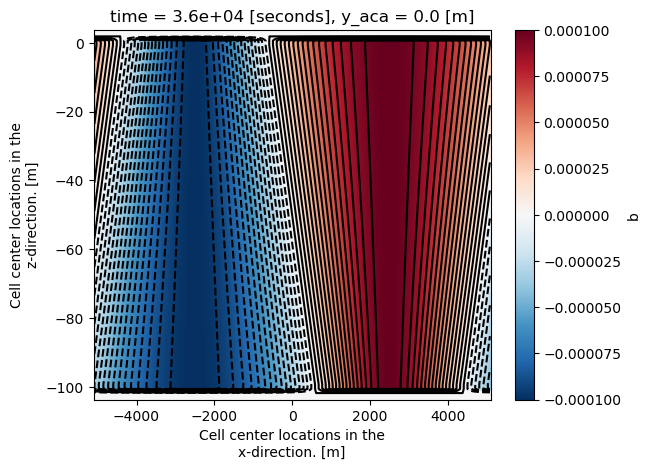

In [78]:
it = 10
ds.b[it,:,0,:].plot(vmin = -1e-4, vmax = 1e-4,cmap='RdBu_r')
ds.b[it,:,0,:].plot.contour(colors='k',levels=40)

In [82]:
ds.to_netcdf('/Users/lbaker/Documents/Edinburgh/Teaching/Tom_project/Frontogenesis/combined_output_filtered_Eulerian_Lagrangian_Ro_0_1_B00.nc')